In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Checking available result files...
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/activation_stats.csv
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/before_after_filtering_summary.csv
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/concept_consistency_unfiltered.csv
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/concept_consistency_filtered.csv
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/generalness_unfiltered.csv
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/generalness_filtered.csv
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/image_concepts_unfiltered.csv
✅ Found /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval/image_concepts_filtered.csv
✅ Found /co

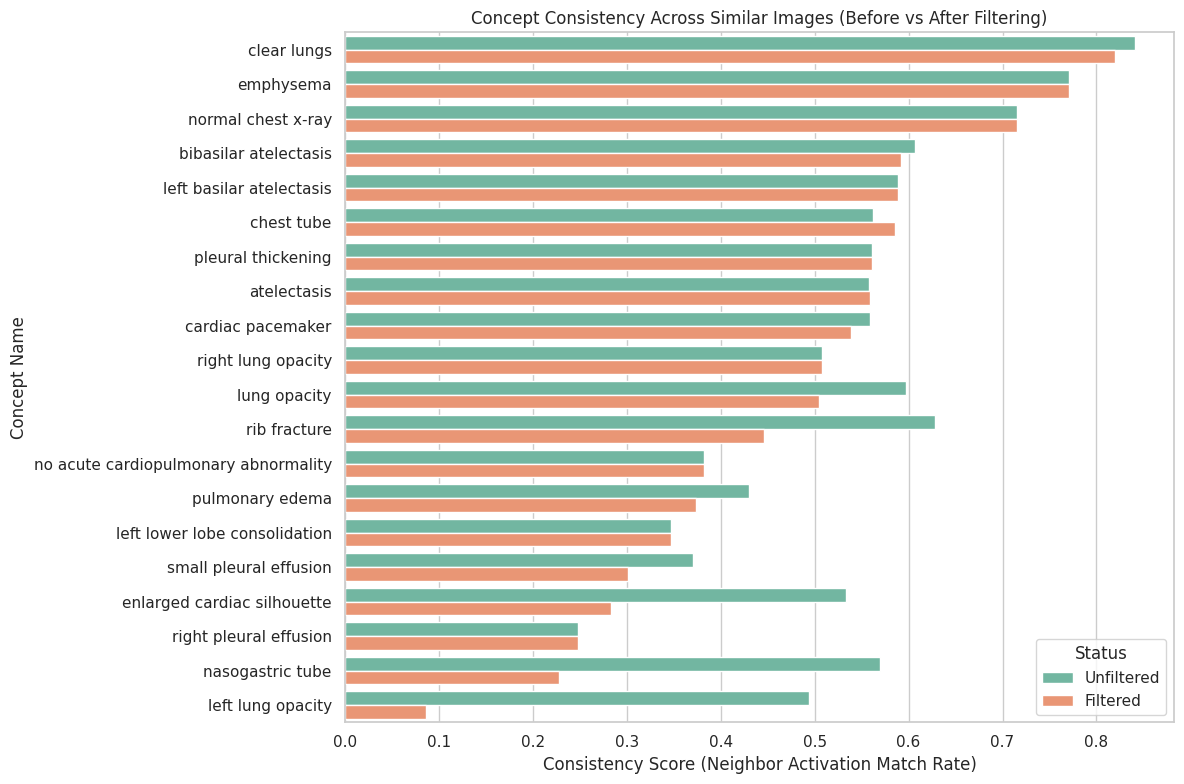

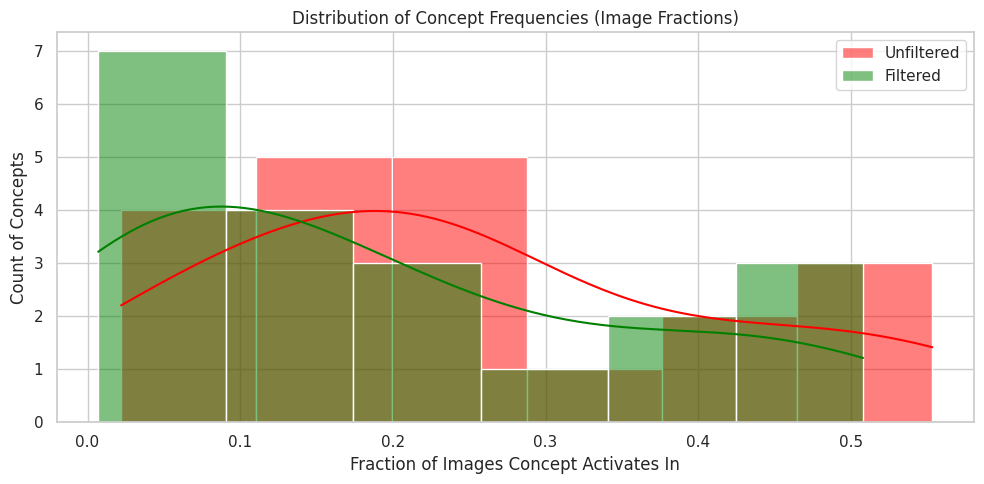

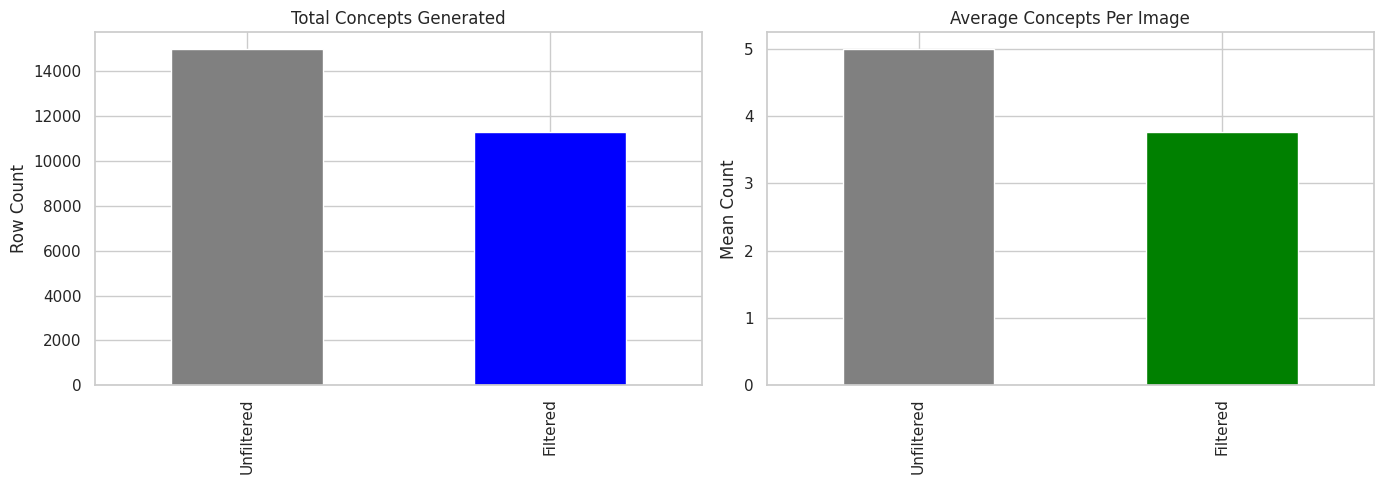


=== Qualitative Explanation Comparison for img_000000 ===

--- UNFILTERED ---
 rank               concept  activation
    1          lung opacity    0.151173
    2    right lung opacity    0.122952
    3             emphysema    0.117589
    4 bibasilar atelectasis    0.096904
    5     cardiac pacemaker    0.096776

--- FILTERED ---
 rank               concept  activation
    1          lung opacity    0.151173
    2    right lung opacity    0.122952
    3             emphysema    0.117589
    4 bibasilar atelectasis    0.096904
    5     cardiac pacemaker    0.096776


In [24]:
# @title Medical VLM Concept Reliability Evaluation
# @markdown Run this notebook to parse, analyze, and visualize the concept metrics before and after filtering.

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from collections import defaultdict

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Define the base path to the data folder in Google Drive
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part2_full_eval'
# Ensure OUTPUT_PATH is accessible here
OUTPUT_PATH = '/content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3'
os.makedirs(OUTPUT_PATH, exist_ok=True)

files_needed = [
    'activation_stats.csv', 'before_after_filtering_summary.csv',
    'concept_consistency_unfiltered.csv', 'concept_consistency_filtered.csv',
    'generalness_unfiltered.csv', 'generalness_filtered.csv',
    'image_concepts_unfiltered.csv', 'image_concepts_filtered.csv',
    'similar_image_consistency_pairs.csv', 'sae_activations.npy'
]

print("Checking available result files...")
for f in files_needed:
    full_path = os.path.join(DATA_PATH, f)
    if os.path.exists(full_path):
        print(f"✅ Found {full_path}")
    else:
        print(f"⚠️ Missing {full_path} (some fallbacks may be used)")

# --- CORRECTED FILTERING PIPELINE ---
print("\n[Corrected Pipeline] Re-filtering concepts and recomputing metrics to address the quota padding bug...")

# 1. Load raw datasets
df_img_unfilt = pd.read_csv(os.path.join(DATA_PATH, 'image_concepts_unfiltered.csv'))
df_pairs = pd.read_csv(os.path.join(DATA_PATH, 'similar_image_consistency_pairs.csv'))

# 2. Load activations to compute the correct threshold for each image
activations_path = os.path.join(DATA_PATH, 'sae_activations.npy')
if os.path.exists(activations_path):
    print("Loading sae_activations.npy...")
    activations = np.load(activations_path)
    image_means = activations.mean(axis=1)
    image_stds = activations.std(axis=1)
    def get_threshold(img_id):
        idx = int(img_id.split('_')[-1])
        return max(image_means[idx] + 1.5 * image_stds[idx], 0.01)
else:
    print("sae_activations.npy not found, falling back to threshold mapping from image_concepts_filtered.csv...")
    df_filt_orig = pd.read_csv(os.path.join(DATA_PATH, 'image_concepts_filtered.csv'))
    threshold_map = df_filt_orig.groupby('image_id')['image_threshold'].first().to_dict()
    def get_threshold(img_id):
        return threshold_map.get(img_id, 0.01)

df_img_unfilt['image_threshold'] = df_img_unfilt['image_id'].apply(get_threshold)

# 3. Apply correct filtering: status == 'assigned' and activation >= image_threshold
# (Keep only top concepts from the top 20, do not scan deeper to pad to 5!)
df_img_filt = df_img_unfilt[
    (df_img_unfilt['status'] == 'assigned') &
    (df_img_unfilt['activation'] >= df_img_unfilt['image_threshold'])
].copy()

# Re-rank the filtered concepts for each image
df_img_filt['rank'] = df_img_filt.groupby('image_id').cumcount() + 1

# 4. Recompute concept-level consistency using the neighbors mapping
image_neighbors = df_pairs.groupby('image_id')['neighbor_image_id'].apply(list).to_dict()

def compute_consistency(df_concepts):
    concept_sets = df_concepts.groupby('image_id')['concept'].apply(set).to_dict()
    all_image_ids = df_pairs['image_id'].unique()
    for img_id in all_image_ids:
        if img_id not in concept_sets:
            concept_sets[img_id] = set()

    unique_concepts = df_concepts['concept'].unique()
    rows = []
    for concept in unique_concepts:
        images_with_concept = [img for img in concept_sets if concept in concept_sets[img]]

        if len(images_with_concept) == 0:
            rows.append({
                'concept': concept,
                'image_count': 0,
                'neighbor_checks': 0,
                'same_concept_neighbor_count': 0,
                'concept_consistency': 0.0
            })
            continue

        checks = 0
        same = 0
        for img in images_with_concept:
            neighbors = image_neighbors.get(img, [])
            for neighbor in neighbors:
                checks += 1
                if concept in concept_sets.get(neighbor, set()):
                    same += 1

        consistency = same / checks if checks > 0 else 0.0
        rows.append({
            'concept': concept,
            'image_count': len(images_with_concept),
            'neighbor_checks': checks,
            'same_concept_neighbor_count': same,
            'concept_consistency': consistency
        })
    return pd.DataFrame(rows).sort_values(by='concept_consistency', ascending=False)

df_cons_unfilt = compute_consistency(df_img_unfilt)
df_cons_filt = compute_consistency(df_img_filt)

# Merge consistency results for comparison plotting
df_cons_compare = pd.merge(
    df_cons_unfilt[['concept', 'concept_consistency']],
    df_cons_filt[['concept', 'concept_consistency']],
    on='concept',
    suffixes=('_unfiltered', '_filtered')
).sort_values(by='concept_consistency_filtered', ascending=False)

# 5. Recompute generalness classification
def compute_generalness(df_concepts):
    num_images = 3000
    counts = df_concepts.groupby('concept')['image_id'].nunique().reset_index(name='image_count')
    counts['image_fraction'] = counts['image_count'] / num_images

    def label_generalness(frac):
        if frac > 0.80:
            return 'over_activated'
        elif frac > 0.30:
            return 'broad'
        else:
            return 'specific'
    counts['generalness_label'] = counts['image_fraction'].apply(label_generalness)
    return counts.sort_values(by='image_fraction', ascending=False)

df_gen_unfilt = compute_generalness(df_img_unfilt)
df_gen_filt = compute_generalness(df_img_filt)

# 6. Recompute pipeline summary
summary_metrics = {
    'raw_rows': len(df_img_unfilt),
    'filtered_rows': len(df_img_filt),
    'raw_images_with_concepts': df_img_unfilt['image_id'].nunique(),
    'filtered_images_with_concepts': df_img_filt['image_id'].nunique(),
    'raw_unique_concepts': df_img_unfilt['concept'].nunique(),
    'filtered_unique_concepts': df_img_filt['concept'].nunique(),
    'raw_mean_concepts_per_image': len(df_img_unfilt) / 3000,
    'filtered_mean_concepts_per_image': len(df_img_filt) / 3000
}
df_summary = pd.DataFrame([summary_metrics])

# Plotting metrics preparation
summary_metrics_plot = {
    'Rows Generated': [df_summary['raw_rows'].iloc[0], df_summary['filtered_rows'].iloc[0]],
    'Avg Concepts/Image': [df_summary['raw_mean_concepts_per_image'].iloc[0], df_summary['filtered_mean_concepts_per_image'].iloc[0]]
}
df_summary_plot = pd.DataFrame(summary_metrics_plot, index=['Unfiltered', 'Filtered'])

print("Re-filtering and recomputation complete! Generating plots...")

## 2. STEP 4 & 6: CONCEPT CONSISTENCY EVALUATION
df_melted_cons = pd.melt(df_cons_compare, id_vars=['concept'], value_vars=['concept_consistency_unfiltered', 'concept_consistency_filtered'],
                         var_name='Status', value_name='Consistency Score')
df_melted_cons['Status'] = df_melted_cons['Status'].map({'concept_consistency_unfiltered': 'Unfiltered', 'concept_consistency_filtered': 'Filtered'})

plt.figure(figsize=(12, 8))
sns.barplot(data=df_melted_cons, x='Consistency Score', y='concept', hue='Status', palette='Set2')
plt.title('Concept Consistency Across Similar Images (Before vs After Filtering)')
plt.xlabel('Consistency Score (Neighbor Activation Match Rate)')
plt.ylabel('Concept Name')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'concept_consistency_plot.png'))
plt.show()

## 3. STEP 4 & 5: OVER-ACTIVATION / GENERALNESS ANALYSIS
plt.figure(figsize=(10, 5))
sns.histplot(data=df_gen_unfilt, x='image_fraction', color='red', label='Unfiltered', kde=True, alpha=0.5)
sns.histplot(data=df_gen_filt, x='image_fraction', color='green', label='Filtered', kde=True, alpha=0.5)
plt.title('Distribution of Concept Frequencies (Image Fractions)')
plt.xlabel('Fraction of Images Concept Activates In')
plt.ylabel('Count of Concepts')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'concept_distribution_plot.png'))
plt.show()

## 4. STEP 5 & 6: PIPELINE SUMMARY VISUALIZATION
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_summary_plot['Rows Generated'].plot(kind='bar', ax=ax[0], color=['gray', 'blue'])
ax[0].set_title('Total Concepts Generated')
ax[0].set_ylabel('Row Count')

df_summary_plot['Avg Concepts/Image'].plot(kind='bar', ax=ax[1], color=['gray', 'green'])
ax[1].set_title('Average Concepts Per Image')
ax[1].set_ylabel('Mean Count')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pipeline_summary_metrics_plot.png'))
plt.show()

## 5. STEP 6: QUALITATIVE SAMPLES
sample_image_id = df_img_unfilt['image_id'].iloc[0]

print(f"\n=== Qualitative Explanation Comparison for {sample_image_id} ===")
print("\n--- UNFILTERED ---")
print(df_img_unfilt[df_img_unfilt['image_id'] == sample_image_id][['rank', 'concept', 'activation']].head().to_string(index=False))
print("\n--- FILTERED ---")
print(df_img_filt[df_img_filt['image_id'] == sample_image_id][['rank', 'concept', 'activation']].head().to_string(index=False))


In [25]:
# Save the concept consistency comparison results
cons_compare_output_path = os.path.join(OUTPUT_PATH, 'concept_consistency_comparison.csv')
df_cons_compare.to_csv(cons_compare_output_path, index=False)
print(f"Saved Concept Consistency Comparison to: {cons_compare_output_path}")

Saved Concept Consistency Comparison to: /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3/concept_consistency_comparison.csv


In [26]:
# Save the generalness classification results
gen_filt_output_path = os.path.join(OUTPUT_PATH, 'generalness_filtered_classification.csv')
df_gen_filt[['concept', 'image_fraction', 'generalness_label']].to_csv(gen_filt_output_path, index=False)
print(f"Saved Generalness Classification (Filtered) to: {gen_filt_output_path}")

Saved Generalness Classification (Filtered) to: /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3/generalness_filtered_classification.csv


In [27]:
# Save the pipeline execution summary
summary_output_path = os.path.join(OUTPUT_PATH, 'pipeline_summary.csv')
df_summary.to_csv(summary_output_path, index=False)
print(f"Saved Pipeline Summary to: {summary_output_path}")

# Save the summary plot data
summary_plot_output_path = os.path.join(OUTPUT_PATH, 'pipeline_summary_plot_data.csv')
df_summary_plot.to_csv(summary_plot_output_path)
print(f"Saved Pipeline Summary Plot Data to: {summary_plot_output_path}")

Saved Pipeline Summary to: /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3/pipeline_summary.csv
Saved Pipeline Summary Plot Data to: /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3/pipeline_summary_plot_data.csv


In [28]:
# Save the unfiltered image concepts
img_unfilt_output_path = os.path.join(OUTPUT_PATH, 'image_concepts_unfiltered_full.csv')
df_img_unfilt.to_csv(img_unfilt_output_path, index=False)
print(f"Saved Unfiltered Image Concepts to: {img_unfilt_output_path}")

# Save the filtered image concepts
img_filt_output_path = os.path.join(OUTPUT_PATH, 'image_concepts_filtered_full.csv')
df_img_filt.to_csv(img_filt_output_path, index=False)
print(f"Saved Filtered Image Concepts to: {img_filt_output_path}")

Saved Unfiltered Image Concepts to: /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3/image_concepts_unfiltered_full.csv
Saved Filtered Image Concepts to: /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3/image_concepts_filtered_full.csv


## 6. Saving Results

In [29]:
OUTPUT_PATH = '/content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3'
os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f"Output directory created/ensured: {OUTPUT_PATH}")

Output directory created/ensured: /content/drive/MyDrive/Colab Notebooks/xai-project-5-main/outputs_part3
